# Lab5 - Batch Sampling - Solutions by Łukasz Grzegrzolka

Credits:

- the notebook is originally created by Daniel Kałuża
- modified and extended by Sebastian Stawicki and Piotr Biczyk

Until now, we have usually been selecting just one object from the pool in each iteration. However, in practice, due to the cost (in terms of time or other resources) of retraining/fine-tuning the model, this could become a bottleneck for the system.

During this lab class, we will compare different strategies for selecting multiple objects from the pool in each iteration. We will focus on techniques that allow us to achieve a decent gain in model performance in an active learning batch scenario.

## 0. Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 1. Data preparation 

In [2]:
from sklearn.datasets import fetch_openml

bunch = fetch_openml('electricity', return_X_y=False, version=1)
X = bunch.data
y = bunch.target

### Get familiar with the dataset

In [3]:
from IPython.display import display, Markdown

display(Markdown(bunch.DESCR))

**Author**: M. Harries, J. Gama, A. Bifet  
**Source**: [Joao Gama](http://www.inescporto.pt/~jgama/ales/ales_5.html) - 2009  
**Please cite**: None  

**Electricity** is a widely used dataset described by M. Harries and analyzed by J. Gama (see papers below). This data was collected from the Australian New South Wales Electricity Market. In this market, prices are not fixed and are affected by demand and supply of the market. They are set every five minutes. Electricity transfers to/from the neighboring state of Victoria were done to alleviate fluctuations.

The dataset (originally named ELEC2) contains 45,312 instances dated from 7 May 1996 to 5 December 1998. Each example of the dataset refers to a period of 30 minutes, i.e. there are 48 instances for each time period of one day. Each example on the dataset has 5 fields, the day of week, the time stamp, the New South Wales electricity demand, the Victoria electricity demand, the scheduled electricity transfer between states and the class label. The class label identifies the change of the price (UP or DOWN) in New South Wales relative to a moving average of the last 24 hours (and removes the impact of longer term price trends). 

The data was normalized by A. Bifet.

### Attribute information  
* Date: date between 7 May 1996 to 5 December 1998. Here normalized between 0 and 1
* Day: day of the week (1-7)
* Period: time of the measurement (1-48) in half hour intervals over 24 hours. Here normalized between 0 and 1
* NSWprice: New South Wales electricity price, normalized between 0 and 1
* NSWdemand: New South Wales electricity demand, normalized between 0 and 1
* VICprice: Victoria electricity price, normalized between 0 and 1
* VICdemand: Victoria electricity demand, normalized between 0 and 1
* transfer: scheduled electricity transfer between both states, normalized between 0 and 1

### Relevant papers  
M. Harries. Splice-2 comparative evaluation: Electricity pricing. Technical report, The University of South Wales, 1999.  
J. Gama, P. Medas, G. Castillo, and P. Rodrigues. Learning with drift detection. In SBIA Brazilian Symposium on Artificial Intelligence, pages 286–295, 2004.

Downloaded from openml.org.

In [4]:
print(bunch["url"])

https://www.openml.org/d/151


In [5]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45312 entries, 0 to 45311
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   date       45312 non-null  float64 
 1   day        45312 non-null  category
 2   period     45312 non-null  float64 
 3   nswprice   45312 non-null  float64 
 4   nswdemand  45312 non-null  float64 
 5   vicprice   45312 non-null  float64 
 6   vicdemand  45312 non-null  float64 
 7   transfer   45312 non-null  float64 
dtypes: category(1), float64(7)
memory usage: 2.5 MB


In [6]:
X.head()

,date,day,period,nswprice,nswdemand,vicprice,vicdemand,transfer
0,0.0,2,0.000000,0.056443,0.439155,0.003467,0.422915,0.414912
1,0.0,2,0.021277,0.051699,0.415055,0.003467,0.422915,0.414912
2,0.0,2,0.042553,0.051489,0.385004,0.003467,0.422915,0.414912
3,0.0,2,0.063830,0.045485,0.314639,0.003467,0.422915,0.414912
4,0.0,2,0.085106,0.042482,0.251116,0.003467,0.422915,0.414912


### Target distribution

Use bar/histogram-like representation of target distribution.

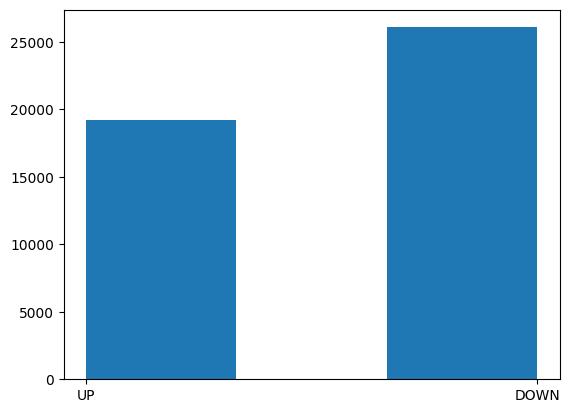

In [7]:
# write your code here

elements, counts = np.unique(y, return_counts=True)
#elements, counts = np.unique(X["period"], return_counts=True)
#print((elements*47.5).astype(int))
#print(counts)

plt.hist(y, bins=3)
plt.xticks(['DOWN', 'UP'])
plt.show()


### Preprocess attributes

Should we preprocess the `day` attribute? Try and check if it is a good idea to:

- use it as it is
- one-hot encode it
- use cyclic encoding (sin/cos)

What about the `period` attribute? Would it be better to cycle encode it?

In [8]:
# write your code here
def encoding_day(day, encoding=None):
    """
    Encodes the day from the data. Valid encodings: "one-hot" and "cyclic".
    """
    if encoding == "one-hot":
        encr = np.zeros(7, dtype=int)
        encr[day - 1] = 1
        return encr
    
    elif encoding == "cyclic":
        sin = np.sin(2 * np.pi * day / 7)
        cos = np.cos(2 * np.pi * day / 7)
        return np.array([sin, cos])
    
    else:
        if encoding is not None:
            print("Invalid encoding: only 'one-hot' and 'cyclic' are valid encoding arguments!")
        return np.array([day])

    
def encoding_period(period, encoding=None):
    """
    Encodes the period from the data. Valid encodings: "one-hot" and "cyclic".
    """
    if encoding == "one-hot":
        encr = np.zeros(48, dtype=int)
        encr[int(period*47.5)] = 1
        return encr
    
    elif encoding == "cyclic":
        sin = np.sin(2 * np.pi * period)
        cos = np.cos(2 * np.pi * period)
        return np.array([sin, cos])
    
    else:
        if encoding is not None:
            print("Invalid encoding: only 'one-hot' and 'cyclic' are valid encoding arguments!")
        return np.array([period])

#encoded = encoding_period(np.linspace(0, 1, 10), "cyclic")    
#print(encoded[0])

### Data preprocessing

In [9]:
#Day preprocessing

day_encoded = np.vstack([encoding_day(d, "cyclic") for d in X["day"].astype(int)])

X["day_sin"] = day_encoded[:, 0]
X["day_cos"] = day_encoded[:, 1]

X = X.drop(columns=["day"])

#period preprocessing
period_encoded = encoding_period(X["period"].astype(float), "cyclic")
X["period_sin"] = period_encoded[0]
X["period_cos"] = period_encoded[1]
X = X.drop(columns=["period"])


X = X.to_numpy()
y = np.where(y=="UP", 1, 0)

### Prepare pool and eval data

Split the dataset into pool and eval subsets (with 60-40 ratio).

Should you use shuffle option when splitting time series data? Propose experiments to verify that.

In [10]:
# write your code here
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(X)

#X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True, stratify=y, random_state=42)
X_train = X[:int(0.6*len(X))]
X_test  = X[int(0.6*len(X)):]
y_train = y[:int(0.6*len(y))]
y_test  = y[int(0.6*len(y)):]


### Informativeness functions

In [11]:
# Informativeness functions

def entropy_informativeness(predictions_probabilities: np.ndarray) -> np.ndarray:
    M = np.zeros(predictions_probabilities.shape[0])
    mask = np.where(np.all(predictions_probabilities != 0, axis=1))
    M[mask] = np.sum(-predictions_probabilities[mask] * np.log(predictions_probabilities[mask]), axis=1)
    return M

def margin_informativeness(predictions_probabilities: np.ndarray) -> np.ndarray:
    return np.ones(predictions_probabilities.shape[0]) - np.sort(predictions_probabilities, axis=1)[:, -1] + np.sort(predictions_probabilities, axis=1)[:, -2]

def random_informativeness(predictions_probabilities: np.ndarray) -> np.ndarray:
    return np.random.uniform(0, 1, predictions_probabilities.shape[0])


#strategie wyboru próbek
def select_top_k(informativeness, k=1):
    idx = np.argsort(-informativeness)[:k]
    return idx

def select_random_k(informativeness, k=1):
    n = len(informativeness)
    idx = np.random.choice(n, size=k, replace=False)
    return idx

In [12]:
prediction_probabilities = np.array([[0.1, 0.9], [0.9, 0.1], [0.7, 0.3]])
weight_1 = 0.75

M_1 = entropy_informativeness(prediction_probabilities)
print(M_1)
M_2 = random_informativeness(prediction_probabilities)
print(M_2)
choices = np.random.choice([0, 1], size=M_1.size, p=[weight_1, 1-weight_1])
idx_1 = select_top_k(M_1)
idx_2 = select_top_k(M_2)
print(np.where(choices==0, idx_1, idx_2))

[0.32508297 0.32508297 0.6108643 ]
[0.47610791 0.00517129 0.11785963]
[2 0 0]


## 2. Create an active learning loop

Prepare a active learning loop with the following properties:
- Logistic Regression is suggested as a classifier of choice (why?)
- use Balanced Accuracy (BAC) as a performance measure
- use batch sampling with a batch size of 20 (you will be selecting 20 objects from the pool in each iteration)
- use 1% of the pool data as the initial training set
- finish the loop after selecting 2% of the pool data (in total it should be 1(initial)+2=3% of the pool data)

Perform experiments with two informativeness functions: 
- one (non-random) of your choice from previous labs
- a random sampling approach

In [13]:
# write your code here
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from tqdm import tqdm


def active_learning_process(X_train,
                            y_train,
                            X_test,
                            y_test,
                            init_batch=0.01,
                            batch_size=20,
                            finish_after_selecting=0.02,
                            classifier = LogisticRegression,
                            performance_metric=balanced_accuracy_score,
                            info_function=entropy_informativeness,
                            add_random_to_batch=False,
                            add_random_probability=0.1,
                            **kwargs
                            ):
    
    idx_init, idx_wait = train_test_split(np.arange(y_train.size), train_size=init_batch)
    X_init, X_wait = X_train[idx_init], X_train[idx_wait]
    y_init, y_wait = y_train[idx_init], y_train[idx_wait]

    clf = classifier(**kwargs)
    performance = np.zeros(int(y_train.size*finish_after_selecting))
    labeled_set_size = np.zeros_like(performance)
    steps = np.arange(performance.size)

    for i in tqdm(range(int(y_train.size/50))):
        clf.fit(X_init, y_init)
        preds = clf.predict(X_test)
        performance[i] = performance_metric(y_test, preds)
        labeled_set_size[i] = X_init.shape[0]

        new_batch_idx = select_top_k(info_function(clf.predict_proba(X_wait)), k=batch_size)
        X_init = np.vstack([X_init, X_wait[new_batch_idx]])
        y_init = np.concatenate([y_init, y_wait[new_batch_idx]])

        mask = np.ones(y_wait.size, dtype=bool)
        mask[new_batch_idx] = False
        X_wait = X_wait[mask]
        y_wait = y_wait[mask]

        if add_random_to_batch:
            random_idx = np.random.randint(0, y_wait.size, size=int(new_batch_idx.size*add_random_probability))
            X_init = np.vstack([X_init, X_wait[random_idx]])
            y_init = np.concatenate([y_init, y_wait[random_idx]])
            
            mask = np.ones(y_wait.size, dtype=bool)
            mask[random_idx] = False
            X_wait = X_wait[mask]
            y_wait = y_wait[mask]

    return steps, labeled_set_size, performance

### Present the results

Create a plot presenting the results of the experiments - BAC value as a function of the number of samples/iterations.

In [14]:
#Perform the experiment
steps_entropy, X_init_size_entropy, performance_entropy = active_learning_process(X_train, y_train, X_test, y_test, info_function=entropy_informativeness, warm_start=True, n_jobs=-1)

steps_margin, X_init_size_margin, performance_margin = active_learning_process(X_train, y_train, X_test, y_test, info_function=margin_informativeness, warm_start=True, n_jobs=-1)

steps_random, X_init_size_random, performance_random = active_learning_process(X_train, y_train, X_test, y_test, info_function=random_informativeness, warm_start=True, n_jobs=-1)

100%|██████████| 543/543 [00:08<00:00, 63.61it/s]


In [15]:
clf_base_test = LogisticRegression(penalty=None, n_jobs=-1).fit(X_test, y_test)
BAC_base_test = balanced_accuracy_score(y_test, clf_base_test.predict(X_test))

clf_base_train = LogisticRegression(penalty=None, n_jobs=-1).fit(X_train, y_train)
BAC_base_train = balanced_accuracy_score(y_test, clf_base_train.predict(X_test))

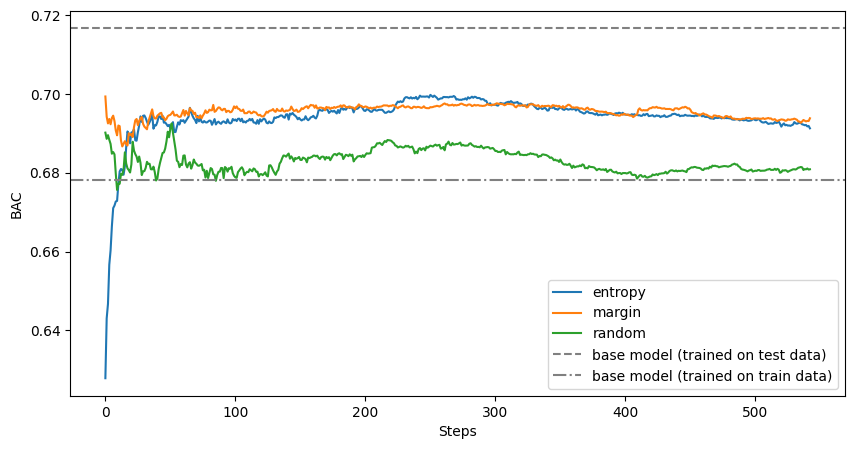

In [16]:
# write your code here
#plot the results
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(steps_entropy, performance_entropy, label="entropy")
ax1.plot(steps_margin, performance_margin, label="margin")
ax1.plot(steps_random, performance_random, label="random")
ax1.axhline(y=BAC_base_test, linestyle="--", color="gray", label="base model (trained on test data)")
ax1.axhline(y=BAC_base_train, linestyle="-.", color="gray", label="base model (trained on train data)")
ax1.set_xlabel("Steps")
ax1.set_ylabel("BAC")
plt.legend()

#ax2.plot(X_init_size_entropy, performance_entropy)
#ax2.set_xlabel("Training dataset size")
#ax2.set_ylabel("BAC")

plt.show()

## 3. Add anther informativeness measure

Now let's inject some random diversity to break ties/clustering among top-uncertain samples.

Create a new informativeness measure as a linear combination of two measures you have already used (a chosen informativeness measure and random informativeness measure), e.g., with weights 1.0 and 0.2, respectively. 

Perform the experiments.

Will the results be better/worse if you change the weights? Try finding the optimal weight for your specific case.

In [17]:
#Perform the experiment
steps_entropy_rand, X_init_size_entropy_rand, performance_entropy_rand = active_learning_process(X_train, y_train, X_test, y_test, info_function=entropy_informativeness, add_random_to_batch=True, add_random_probability=0.2, warm_start=True, n_jobs=-1)


100%|██████████| 543/543 [00:17<00:00, 31.40it/s]


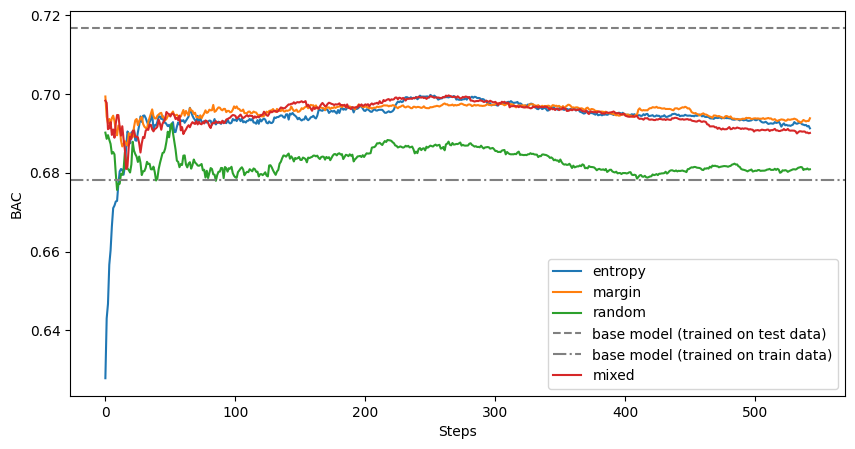

In [18]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(steps_entropy, performance_entropy, label="entropy")
ax1.plot(steps_margin, performance_margin, label="margin")
ax1.plot(steps_random, performance_random, label="random")
ax1.axhline(y=BAC_base_test, linestyle="--", color="gray", label="base model (trained on test data)")
ax1.axhline(y=BAC_base_train, linestyle="-.", color="gray", label="base model (trained on train data)")
ax1.plot(steps_entropy_rand, performance_entropy_rand,label="mixed")
ax1.set_xlabel("Steps")
ax1.set_ylabel("BAC")
plt.legend()
plt.show()

### Present the results

Create a plot presenting the results of the experiments - BAC value as a function of the number of samples/iterations. Compare the results of the three informativeness measures.

In [19]:
# write your code here




## 4*. Introduce iterative distance-based diversity approach 
  
In previous excercise, we were choosing batch samples based on informativeness.

Now you will use a greedy sequential aproach for approximating an optimal choice of a DIVERSE batch.

1. Compute the informativeness score with chosen informativeness measure for every sample in the pool.
2. Select one most informative sample and add it to the batch.
3. Repeat the following steps until the expected batch size is reached:
    - compute the distance of all samples from the pool to the samples chosen to the batch until now
    - compute the sum of informativeness score (computed in step 1) and normalized distance to the samples in the batch
    - choose the sample with the highest score and add it to the batch
4. Examine the distribution of informativeness across the pool of samples.

Please note:
* the normalization in point 3 is not a meaningless detail - it is a design decision. You are combining heretegenous scores, and must take into account scale alignment.
* think how to implement this algorithm in a computationaly efficient way

In [20]:
from scipy.spatial.distance import cdist


A = np.array([[np.sqrt(1/3), np.sqrt(1/3), np.sqrt(1/3)],
              [1, 0, 0],
              [np.sqrt(1/6), np.sqrt(1/6), np.sqrt(2/3)]])

batch = np.array([[np.sqrt(1/3), -np.sqrt(1/3), -np.sqrt(1/3)],
              [0, np.sqrt(1/2), np.sqrt(1/2)]])

distances = np.zeros((A.shape[0], batch.shape[0]))

for i, v in enumerate(A):
    #print( batch-v )
    #print(np.sqrt(np.sum( (batch-v)**2, axis=1 )))
    distances[i] = np.sqrt(np.sum( (batch-v)**2, axis=1 ))

#print(distances)
#print(np.sum(distances, axis=1))
#print(np.sum(distances, axis=1) / (2*np.sqrt(np.sum( np.max( A**2 , axis=0) ))))

#print( np.max( A**2 , axis=0) ) 
#print( 2*np.sqrt(np.sum( np.max( A**2 , axis=0) )) )

def distance(X_batch, X_pool):
    # macierz odległości: shape = (len(X_batch), len(X_pool))
    D = cdist(X_batch, X_pool, metric='euclidean')
    # suma odległości do każdego punktu z X_pool
    distances = D.sum(axis=0)
    # normalizacja względem rozpiętości zbioru X_pool
    return distances / (2 * np.sqrt(np.sum(np.max(X_pool**2, axis=0))))



def distance_0(X_batch, X_pool):
    distances = np.zeros(X_pool.shape[0])
    norm = 2*np.sqrt(np.sum( np.max( X_pool**2 , axis=0) ))     #normalizacja względem rozpiętosci danych w X_pool
    for i, v in enumerate(X_pool):
        distances[i] = np.sum(np.sqrt(np.sum( (X_batch-v)**2, axis=1 ))) / norm        #sumy odległości kolejnych wektorów z X_pool od wszystkich wektorów z X_batch, znormalizowana względem ropiętości 
    return distances

print(distance_0(batch, A))
print(distance(batch, A))

p = entropy_informativeness(A)
d = distance(batch, A)
print(p+d)

idx = [0, 2]
print(d[idx])

l = [i for i in range(10)][::-1]
z = [0, 3, 4]
s = [ i for i in l if i not in z ]
print(l)
print(z)
print( s )

[0.79153676 0.82505758 0.78952002]
[0.79153676 0.82505758 0.78952002]
[1.74296292 0.82505758 1.6865332 ]
[0.79153676 0.78952002]
[9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
[0, 3, 4]
[9, 8, 7, 6, 5, 2, 1]


In [52]:
# write your code here

def active_learning_process(X_train,
                            y_train,
                            X_test,
                            y_test,
                            init_batch=0.01,
                            batch_size=20,
                            finish_after_selecting=0.02,
                            classifier = LogisticRegression,
                            performance_metric=balanced_accuracy_score,
                            info_function=entropy_informativeness,
                            add_random_to_batch=False,
                            greedy_approach=False,
                            diversity_factor=0.3,
                            add_random_probability=0.1,
                            **kwargs
                            ):
    
    idx_init, idx_wait = train_test_split(np.arange(y_train.size), train_size=init_batch)
    X_init, X_wait = X_train[idx_init], X_train[idx_wait]
    y_init, y_wait = y_train[idx_init], y_train[idx_wait]

    clf = classifier(**kwargs)
    performance = np.zeros(int(y_train.size*finish_after_selecting))
    labeled_set_size = np.zeros_like(performance)
    steps = np.arange(performance.size)

    for i in tqdm(range(int(y_train.size*finish_after_selecting))):
        clf.fit(X_init, y_init)
        preds = clf.predict(X_test)
        performance[i] = performance_metric(y_test, preds)
        labeled_set_size[i] = X_init.shape[0]

        if greedy_approach:
            new_batch_idx = []
            pool_informativeness = info_function(clf.predict_proba(X_wait))
            new_batch_idx.append(select_top_k(pool_informativeness, 1)[0])
            while len(new_batch_idx)<batch_size:
                distances = distance(X_wait[new_batch_idx], X_wait)
                scores = distances * diversity_factor + pool_informativeness
                # ustaw bardzo niską wartość dla już wybranych
                scores[new_batch_idx] = -np.inf
                # wybierz najlepszy nowy indeks
                new_batch_idx.append(select_top_k(scores, 1)[0])           
        
        else:
            new_batch_idx = select_top_k(info_function(clf.predict_proba(X_wait)), k=batch_size)
        #print(new_batch_idx)
        X_init = np.vstack([X_init, X_wait[new_batch_idx]])
        y_init = np.concatenate([y_init, y_wait[new_batch_idx]])

        mask = np.ones(y_wait.size, dtype=bool)
        mask[new_batch_idx] = False
        X_wait = X_wait[mask]
        y_wait = y_wait[mask]

        if add_random_to_batch:
            random_idx = np.random.randint(0, y_wait.size, size=int(new_batch_idx.size*add_random_probability))
            X_init = np.vstack([X_init, X_wait[random_idx]])
            y_init = np.concatenate([y_init, y_wait[random_idx]])
            
            mask = np.ones(y_wait.size, dtype=bool)
            mask[random_idx] = False
            X_wait = X_wait[mask]
            y_wait = y_wait[mask]

    return steps, labeled_set_size, performance

#steps_entropy_greedy_01, X_init_size_entropy_greedy_01, performance_entropy_greedy_01 = active_learning_process(X_train, y_train, X_test, y_test, info_function=entropy_informativeness, greedy_approach=True, diversity_factor=0.1, warm_start=True, n_jobs=-1)


In [ ]:
steps_entropy_greedy_2, X_init_size_entropy_greedy_2, performance_entropy_greedy_2 = active_learning_process(X_train, y_train, X_test, y_test, info_function=entropy_informativeness, greedy_approach=True, diversity_factor=2, warm_start=True, n_jobs=-1)
steps_entropy_greedy_1, X_init_size_entropy_greedy_1, performance_entropy_greedy_1 = active_learning_process(X_train, y_train, X_test, y_test, info_function=entropy_informativeness, greedy_approach=True, diversity_factor=1, warm_start=True, n_jobs=-1)
steps_entropy_greedy_05, X_init_size_entropy_greedy_05, performance_entropy_greedy_05 = active_learning_process(X_train, y_train, X_test, y_test, info_function=entropy_informativeness, greedy_approach=True, diversity_factor=0.5, warm_start=True, n_jobs=-1)
steps_entropy_greedy_01, X_init_size_entropy_greedy_01, performance_entropy_greedy_01 = active_learning_process(X_train, y_train, X_test, y_test, info_function=entropy_informativeness, greedy_approach=True, diversity_factor=0.1, warm_start=True, n_jobs=-1)
steps_entropy_greedy_001, X_init_size_entropy_greedy_001, performance_entropy_greedy_001 = active_learning_process(X_train, y_train, X_test, y_test, info_function=entropy_informativeness, greedy_approach=True, diversity_factor=0.01, warm_start=True, n_jobs=-1)
steps_entropy_greedy_0001, X_init_size_entropy_greedy_0001, performance_entropy_greedy_0001 = active_learning_process(X_train, y_train, X_test, y_test, info_function=entropy_informativeness, greedy_approach=True, diversity_factor=0.001, warm_start=True, n_jobs=-1)


100%|██████████| 543/543 [00:29<00:00, 18.65it/s]


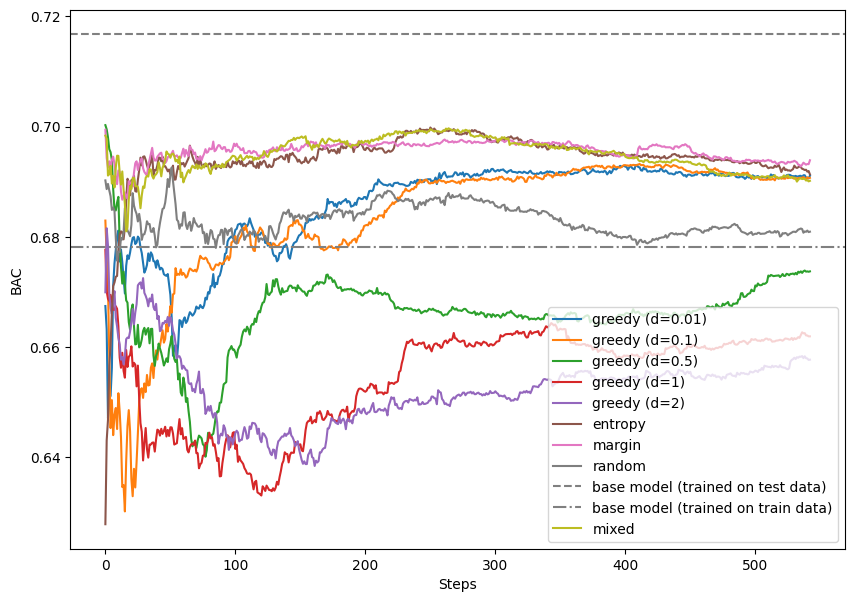

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 10))

ax1.plot(steps_entropy_greedy_0001, performance_entropy_greedy_0001, label="greedy (d=0.001)")
ax1.plot(steps_entropy_greedy_001, performance_entropy_greedy_001, label="greedy (d=0.01)")
ax1.plot(steps_entropy_greedy_01, performance_entropy_greedy_01, label="greedy (d=0.1)")
ax1.plot(steps_entropy_greedy_05, performance_entropy_greedy_05, label="greedy (d=0.5)")
ax1.plot(steps_entropy_greedy_1, performance_entropy_greedy_1, label="greedy (d=1)")
ax1.plot(steps_entropy_greedy_2, performance_entropy_greedy_2, label="greedy (d=2)")
ax1.plot(steps_entropy, performance_entropy, label="entropy")
ax1.plot(steps_margin, performance_margin, label="margin")
ax1.plot(steps_random, performance_random, label="random")
ax1.axhline(y=BAC_base_test, linestyle="--", color="gray", label="base model (trained on test data)")
ax1.axhline(y=BAC_base_train, linestyle="-.", color="gray", label="base model (trained on train data)")
ax1.plot(steps_entropy_rand, performance_entropy_rand,label="mixed")
ax1.set_xlabel("Steps")
ax1.set_ylabel("BAC")
plt.legend()
plt.show()

## 5*. Introduce a simple representativeness approach

Here you should do something different - pick a batch based on its REPRESENTATIVENESS. In previous excercise, the diversity measure might show us outliers. Here we want to look for samples that are informative about large areas of the feature space.

Prepre a new informativeness measure that is a linear combination of the selected informativeness measure and the distance-based score (average distance to every other sample in the pool). 

In [70]:
# write your code here

def active_learning_process_repr(X_train,
                            y_train,
                            X_test,
                            y_test,
                            init_batch=0.01,
                            batch_size=20,
                            finish_after_selecting=0.02,
                            classifier = LogisticRegression,
                            performance_metric=balanced_accuracy_score,
                            info_function=entropy_informativeness,
                            add_random_to_batch=False,
                            representative_approach=True,
                            diversity_factor=0.3,
                            add_random_probability=0.1,
                            **kwargs
                            ):
    
    idx_init, idx_wait = train_test_split(np.arange(y_train.size), train_size=init_batch)
    X_init, X_wait = X_train[idx_init], X_train[idx_wait]
    y_init, y_wait = y_train[idx_init], y_train[idx_wait]

    clf = classifier(**kwargs)
    performance = np.zeros(int(y_train.size*finish_after_selecting))
    labeled_set_size = np.zeros_like(performance)
    steps = np.arange(performance.size)

    for i in tqdm(range(int(y_train.size*finish_after_selecting))):
        clf.fit(X_init, y_init)
        preds = clf.predict(X_test)
        performance[i] = performance_metric(y_test, preds)
        labeled_set_size[i] = X_init.shape[0]

        if representative_approach:
            new_batch_idx = np.array([], dtype=int)
            pool_informativeness = info_function(clf.predict_proba(X_wait))
            new_batch_idx = np.concatenate([new_batch_idx ,select_top_k(pool_informativeness, 2)])

            while len(new_batch_idx)<batch_size:
                distances = distance(X_wait[new_batch_idx], X_wait)
                scores = diversity_factor / distances + pool_informativeness
                # ustaw bardzo niską wartość dla już wybranych
                scores[new_batch_idx] = -np.inf
                # wybierz najlepszy nowy indeks
                new_batch_idx = np.concatenate([new_batch_idx ,select_top_k(scores, 1)])             
        
        else:
            new_batch_idx = select_top_k(info_function(clf.predict_proba(X_wait)), k=batch_size)
        #print(new_batch_idx)
        X_init = np.vstack([X_init, X_wait[new_batch_idx]])
        y_init = np.concatenate([y_init, y_wait[new_batch_idx]])

        mask = np.ones(y_wait.size, dtype=bool)
        mask[new_batch_idx] = False
        X_wait = X_wait[mask]
        y_wait = y_wait[mask]

        if add_random_to_batch:
            random_idx = np.random.randint(0, y_wait.size, size=int(new_batch_idx.size*add_random_probability))
            X_init = np.vstack([X_init, X_wait[random_idx]])
            y_init = np.concatenate([y_init, y_wait[random_idx]])
            
            mask = np.ones(y_wait.size, dtype=bool)
            mask[random_idx] = False
            X_wait = X_wait[mask]
            y_wait = y_wait[mask]

    return steps, labeled_set_size, performance

#steps_entropy_repr_1, X_init_size_entropy_repr_1, performance_entropy_repr_1 = active_learning_process_repr(X_train, y_train, X_test, y_test, info_function=entropy_informativeness, representative_approach=True, diversity_factor=1, warm_start=True, n_jobs=-1)


In [71]:
steps_entropy_repr_2, X_init_size_entropy_repr_2, performance_entropy_repr_2 = active_learning_process_repr(X_train, y_train, X_test, y_test, info_function=entropy_informativeness, representative_approach=True, diversity_factor=2, warm_start=True, n_jobs=-1)
steps_entropy_repr_1, X_init_size_entropy_repr_1, performance_entropy_repr_1 = active_learning_process_repr(X_train, y_train, X_test, y_test, info_function=entropy_informativeness, representative_approach=True, diversity_factor=1, warm_start=True, n_jobs=-1)
steps_entropy_repr_01, X_init_size_entropy_repr_01, performance_entropy_repr_01 = active_learning_process_repr(X_train, y_train, X_test, y_test, info_function=entropy_informativeness, representative_approach=True, diversity_factor=0.1, warm_start=True, n_jobs=-1)
steps_entropy_repr_001, X_init_size_entropy_repr_001, performance_entropy_repr_001 = active_learning_process_repr(X_train, y_train, X_test, y_test, info_function=entropy_informativeness, representative_approach=True, diversity_factor=0.01, warm_start=True, n_jobs=-1)


100%|██████████| 543/543 [00:28<00:00, 18.76it/s]


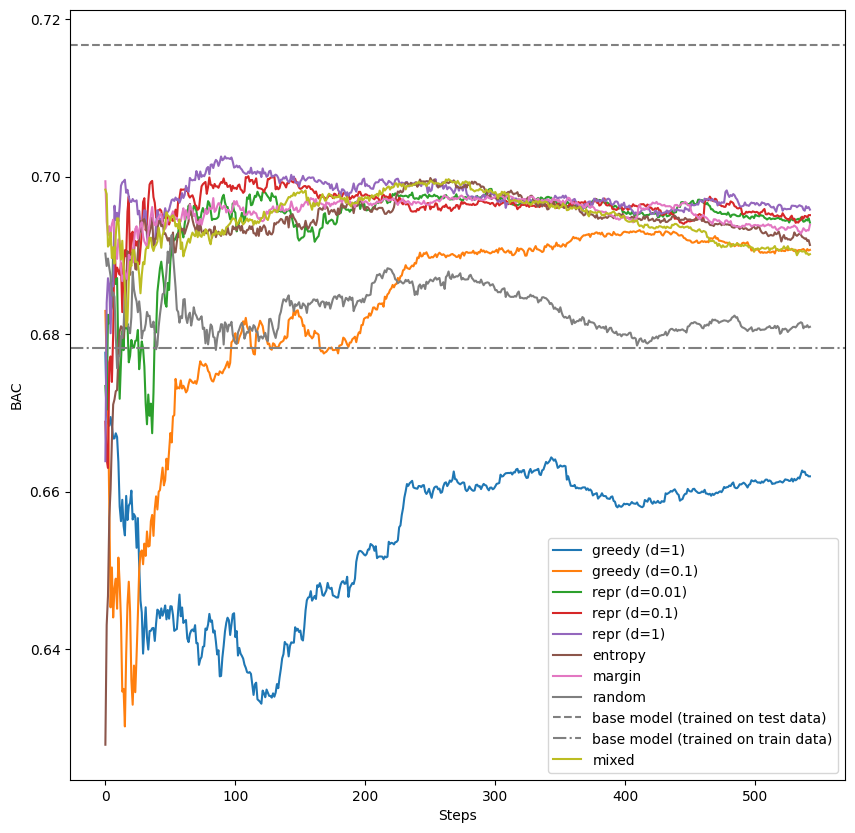

In [73]:
fig, ax1 = plt.subplots(figsize=(10, 10))


ax1.plot(steps_entropy_greedy_1, performance_entropy_greedy_1, label="greedy (d=1)")
ax1.plot(steps_entropy_greedy_01, performance_entropy_greedy_01, label="greedy (d=0.1)")
ax1.plot(steps_entropy_repr_001, performance_entropy_repr_001, label="repr (d=0.01)")
ax1.plot(steps_entropy_repr_01, performance_entropy_repr_01, label="repr (d=0.1)")
ax1.plot(steps_entropy_repr_1, performance_entropy_repr_1, label="repr (d=1)")
ax1.plot(steps_entropy, performance_entropy, label="entropy")
ax1.plot(steps_margin, performance_margin, label="margin")
ax1.plot(steps_random, performance_random, label="random")
ax1.axhline(y=BAC_base_test, linestyle="--", color="gray", label="base model (trained on test data)")
ax1.axhline(y=BAC_base_train, linestyle="-.", color="gray", label="base model (trained on train data)")
ax1.plot(steps_entropy_rand, performance_entropy_rand,label="mixed")
ax1.set_xlabel("Steps")
ax1.set_ylabel("BAC")
plt.legend()
plt.show()

## 6*. Finishing touches

In real-world examples, you can combine the three techniques. S(x) = I_norm(x) + α · D_norm(x) + β · R_norm(x)

Pure entropy selects near the decision boundary, entropy + diversity spreads along the boundary, entropy + representativeness selects near the boundary but biased toward dense regions. To visualize differences - project your pool from each strategy onto 2 dimensions using PCA or t-SNE, then scatter-plot all pool samples in gray and overlay the 20 selected batch members as colored markers — one color per strategy. Do this side-by-side for pure entropy, entropy+diversity, and entropy+representativeness on the same iteration.